# 张量网络（torch）

In [10]:
import quante as qt
import quante.bridge.torch_utils as qtc
import numpy as np
import torch as tc
from tqdm import tqdm
op = qt.generate.operas

## 第一部分 MPS

建立随机 mps

In [11]:
L = 100
𝜓 = qtc.MPS.from_random(L, bond_dim=4, dtype=tc.float64, device='cpu')
𝜓.show()

MPS;  torch.float64;  norm: 8.166e+43;  maxbonddim: 4;  device: cpu;
physdim:    2|    2|    ...   2|    2| 
         ----O-----O--- ... ---O-----O----
bonddim:  1     4    4  ...  4    4     1
site:        0     1    ...    98    99 


建立一些常用的 mps

In [12]:
qtc.MPS.from_ghz_state(L=3)  # |000> + |111>
qtc.MPS.from_w_state(L=3, which='up')  # |001> + |010> + |100>
qtc.MPS.from_w_state(L=3, which='down')  # |110> + |101> + |011>
qtc.MPS.from_vector(tc.randn(2**4, dtype=tc.complex128)) 
qtc.MPS.from_product_state(['up', 'down']*5)  # |1010101010>

MPS;  torch.float64;  norm: 1.000e+00;  maxbonddim: 1;  device: cpu;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2| 
         ----O-----O-----O-----O-----O-----O-----O-----O-----O-----O----
bonddim:  1     1     1     1     1     1     1     1     1     1     1
site:        0     1     2     3     4     5     6     7     8     9  

移动正交中心

In [13]:
𝜓.orthogonalize_(0)
𝜓

MPS;  torch.float64;  norm: 8.166e+43;  maxbonddim: 4;  device: cpu;
physdim:    2|    2|    2|    ...   2|    2| 
         ----O----<|----<|--- ... --<|----<|----
bonddim:  1     4     4    4  ...  4    2     1
site:        0     1     2    ...    98    99 

计算 norm，归一化

In [14]:
𝜓.norm()

tensor(8.1658e+43, dtype=torch.float64)

In [15]:
𝜓.normalize_()
𝜓.norm()

tensor(1., dtype=torch.float64)

计算纠缠熵

In [16]:
𝜓.entanglement_entropy(range(1,L))

[tensor(0.5415, dtype=torch.float64),
 tensor(0.6502, dtype=torch.float64),
 tensor(0.8144, dtype=torch.float64),
 tensor(0.9073, dtype=torch.float64),
 tensor(1.0994, dtype=torch.float64),
 tensor(1.0986, dtype=torch.float64),
 tensor(0.9505, dtype=torch.float64),
 tensor(0.8363, dtype=torch.float64),
 tensor(0.8429, dtype=torch.float64),
 tensor(0.4315, dtype=torch.float64),
 tensor(0.6683, dtype=torch.float64),
 tensor(0.5939, dtype=torch.float64),
 tensor(0.6140, dtype=torch.float64),
 tensor(0.4920, dtype=torch.float64),
 tensor(0.6067, dtype=torch.float64),
 tensor(0.5593, dtype=torch.float64),
 tensor(0.5160, dtype=torch.float64),
 tensor(0.9820, dtype=torch.float64),
 tensor(0.9233, dtype=torch.float64),
 tensor(0.5585, dtype=torch.float64),
 tensor(0.3596, dtype=torch.float64),
 tensor(0.4009, dtype=torch.float64),
 tensor(0.7062, dtype=torch.float64),
 tensor(0.7800, dtype=torch.float64),
 tensor(0.8741, dtype=torch.float64),
 tensor(0.7812, dtype=torch.float64),
 tensor(0.90

计算局域观测量

In [17]:
𝜓.measure('x',0)
𝜓.measure('xx',0)
𝜓.measure(['x', 'x'],[0, 2])

tensor(-0.0557, dtype=torch.float64)

In [18]:
𝜓.measure(op.heisenberg_operator(L))

tensor(1.5447, dtype=torch.float64)

In [19]:
𝜓.measure(np.random.randn(4,4), 0)

tensor(-0.6837, dtype=torch.float64)

In [21]:
𝜓.measure(qtc.MPO.from_random(L=2, bond_dim=2, dtype=tc.float64), 1)

AssertionError: should be 1

In [12]:
tmp = qtc.MPS.from_product_state(['up', 'down']*5)  # |1010101010>
[tmp.measure('Z',i).item() for i in range(10)]

[1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 1.0, -1.0, 1.0, -1.0]

作用局域门

In [13]:
mat = tc.randn(4,4, dtype=tc.float64)
n𝜓 = 𝜓.copy()  # 复制原来的 𝜓
n𝜓.apply_gate_(0, mat)  # 在 (0,1) 位置作用一个 4x4 的矩阵

内积

In [14]:
show(𝜓.inner(n𝜓))  # < ψ | nψ >
𝜓.measure(mat, 0)  # 与内积结果相同

tensor(-0.4004, dtype=torch.float64)


tensor(-0.4004, dtype=torch.float64)

tebd

100%|##########| 100/100 [00:01<00:00, 90.17it/s]


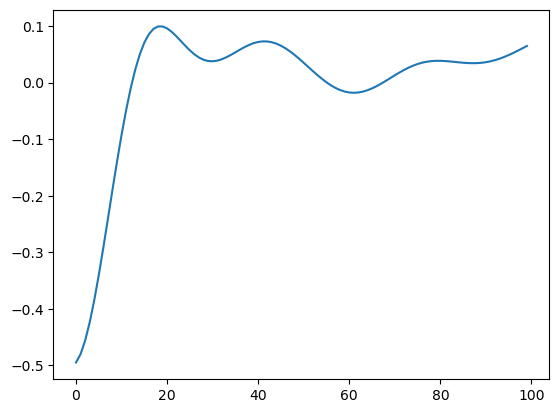

In [15]:
ham = op.heisenberg_operator(L)
𝜓t = qtc.MPS.from_product_state(["up", "down"]*(L//2), dtype=tc.complex128)
gates = ham.trotter_gates(L, tau=0.1, pauli=False)
res = []
for i in tqdm(range(100), ascii=True):
    for pos, gate in zip(*gates):
        𝜓t.apply_gate_(pos, gate)
    res.append(𝜓t.measure('z', 3).item().real)
import matplotlib.pyplot as plt
plt.plot(res)

## itebd

100%|##########| 200/200 [00:04<00:00, 40.41it/s] 


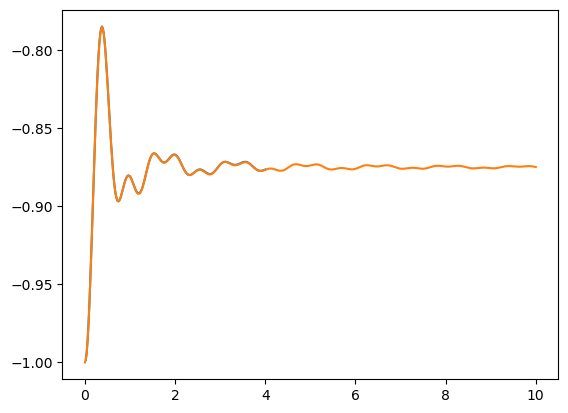

In [16]:
# 生成无穷长 MPS
tmp1 = tc.zeros(1,2,1, dtype=tc.complex128, device='cpu')
tmp1[0,1,0] = 1.
tmp2 = tc.zeros(1,2,1, dtype=tc.complex128, device='cpu')
tmp2[0,1,0] = 1.

psi = qtc.MPS([tmp1, tmp2], [tc.tensor(1., dtype=tc.float64, device='cpu'), tc.tensor(1., dtype=tc.float64, device='cpu')], L=tc.inf)

# 生成两体门
g = 2
ham = op.xx(0,1) + 0.5 * g * op.z(0) + 0.5 * g * op.z(1)
basis = qt.generate.basis.spin_basis(2)
mat = ham.to_matrix(basis, pauli=True)
t = 0.02  # 0.05 会有明显误差
expiH = tc.tensor(qt.linalg.expm(mat, -1j*t), dtype=tc.complex128, device='cpu').reshape(2,2,2,2)

# itebd 演化
ts = []
sz = []
bonds = []
cur_t = 0
for i in tqdm(range(200), ascii=True):
    psi.apply_gate_(0, expiH, svd_alg='svd', trunc_para=(500,1e-8,None), unitary_gate=True)
    psi.apply_gate_(1, expiH, svd_alg='svd', trunc_para=(500,1e-8,None), unitary_gate=True)
    cur_t += t
    sz.append(psi.measure('Z', 0).real)
    ts.append(cur_t)
    bonds.append(psi.maxbonddim())
import matplotlib.pyplot as plt
plt.plot(ts, sz)

#############################
# 对比严格解
#############################
import scipy.integrate as spi
jx = 1
jy = 0
hz = 2
λ = (jx + jy)/2
γ = (jx - jy)/2
theta = lambda k: np.arctan2(2*γ*np.sin(k),  hz - 2*λ*np.cos(k))
omega = lambda k: 2 * np.sqrt((2*γ*np.sin(k))**2 + (hz - 2*λ*np.cos(k))**2)
ts = np.linspace(0, 10, 500)
sigma_zs = np.zeros_like(ts, dtype=np.float64)
for i, t in enumerate(ts):
    sigma_zs[i] = 1/np.pi * spi.quad(lambda k: np.sin(theta(k))**2 * np.sin(omega(k) * t)**2, -np.pi, np.pi)[0] - 1
plt.plot(ts, sigma_zs)

# # 运行时间 2m 22.2s

## 第二部分 MPO

使用 automata 建立一个 mpo

In [17]:
ham = op.heisenberg_operator(L)

In [18]:
ℋ = ham.to_mpo(pauli=False).to_torch(device='cpu')
eng, vec1 = ℋ.dmrg()
ℋ

Sweep 4: 100%|##########| 22/22 [00:00<00:00, 329.87it/s, pE=-5.1421e+00, chi=23]

Energy converged to -5.1420906321 after 4 sweeps.


MPO;  torch.float64;  norm: 9.191e+01;  maxbonddim: 5;  device: cpu;
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2| 
         ----O-----O-----O-----O-----O-----O-----O-----O-----O-----O-----O-----O----
physdim:    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2|    2| 
bonddim:  1     4     5     5     5     5     5     5     5     5     5     5     1
site:        0     1     2     3     4     5     6     7     8     9     10    11 

也可以使用 quimb 建立 mpo

In [ ]:
# ham = op.heisenberg_operator(L)
# quimbH = ham.to_mpo(pauli=False).to_quimb()
# quimbH.draw()

计算内积

In [20]:
L = 100
ham = op.heisenberg_operator(L) + op.y(0)
H = ham.to_mpo(pauli=False).to_torch('cpu')
psi = qtc.MPS.from_random(L, bond_dim=4)

H.mele(psi, psi)  # <psi|H|psi>

tensor(-1.8571e+88+9.7177e+72j, dtype=torch.complex128)

In [21]:
# import quimb.tensor as qtn
# Hq = H.to_quimb()
# psiq:qtn.MatrixProductState = psi.to_quimb()

# dagpsiq = psiq.conj().reindex({f"k{i}":f"b{i}" for i in range(L)})
# Hq = Hq.reindex({
#     **{f"k{i}":f"b{i}" for i in range(L)},
#     **{f"b{i}":f"k{i}" for i in range(L)}
#     })
# (dagpsiq | Hq | psiq).draw(show_tags=False)
# (dagpsiq | Hq | psiq) ^ ...

In [22]:
# tree = (dagpsiq | Hq | psiq).contraction_tree()
# tree.plot_rubberband()

## dmrg

dmrg 算基态

In [23]:
L = 10
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False).to_torch('cpu')
eng, vec = H.dmrg(nsweep=10)
ham.gdenergy(pauli=False)

Sweep 3: 100%|##########| 18/18 [00:00<00:00, 360.02it/s, pE=-4.2580e+00, chi=20]


Energy converged to -4.2580352068 after 3 sweeps.


-4.25803520728288

In [24]:
L = 100
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False).to_torch('cpu')
eng, vec = H.dmrg(nsweep=10)

Sweep 1:   0%|          | 0/198 [00:00<?, ?it/s, pE=-1.1743e+00, chi=2]

Sweep 5: 100%|##########| 198/198 [00:01<00:00, 177.33it/s, pE=-4.4128e+01, chi=106]

Energy converged to -44.1277398528 after 5 sweeps.


dmrg 算第一激发态

In [25]:
L = 10
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False).to_torch('cpu')
eng, vec1 = ℋ.dmrg()
eng, vec2 = ℋ.dmrg(Ms=[vec1])
ham.gdenergy(pauli=False, k=2) # ed 结果

Sweep 3: 100%|##########| 18/18 [00:00<00:00, 391.30it/s, pE=-4.2580e+00, chi=20]


Energy converged to -4.2580352068 after 3 sweeps.


Sweep 3: 100%|##########| 18/18 [00:00<00:00, 283.42it/s, pE=-3.9307e+00, chi=20]

Energy converged to -3.9306735895 after 3 sweeps.


array([-3.93067359, -4.25803521])

In [26]:
L = 100
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False).to_torch('cpu')
eng, vec1 = ℋ.dmrg()
eng, vec2 = ℋ.dmrg(Ms=[vec1])

Sweep 5: 100%|##########| 198/198 [00:01<00:00, 181.86it/s, pE=-4.4128e+01, chi=106]


Energy converged to -44.1277398522 after 5 sweeps.


Sweep 5: 100%|##########| 198/198 [00:01<00:00, 157.96it/s, pE=-4.4087e+01, chi=103]

Energy converged to -44.0872991442 after 5 sweeps.


dmrg 算 MPO 求和的基态

In [28]:
L = 10
ham = op.heisenberg_operator(L)
H = ham.to_mpo(pauli=False).to_torch('cpu')
hams = [ham + op.sum(np.random.rand() * op.z(i) for i in range(L)) for _ in range(10)]
mpos = [h.to_mpo().to_torch('cpu') for h in hams]
qtc.DMRG(mpos).run2()

op.sum(hams).gdenergy(pauli=False) # ed 的结果

Sweep 3: 100%|##########| 18/18 [00:00<00:00, 164.19it/s, pE=-4.5679e+01, chi=16]

Energy converged to -45.6794469920 after 3 sweeps.


-45.679446995806266

准一维系统的基态
```
      0   2   4   6
   ---◻---◻---◻---◻---
      |   |   |   |
   ---◻---◻---◻---◻---
      1   3   5   7
```

In [29]:
j1, j2, j3 = 1.0, 2.0, 1.0

for L in range(4, 10):
    
    builder = op.builder()

    for i in range(L-1):
        # S
        builder += 'xx', [2*i, 2*i+2], j1
        builder += 'yy', [2*i, 2*i+2], j1
        builder += 'zz', [2*i, 2*i+2], j1
        # L
        builder += 'xx', [2*i+1, 2*i+3], j2
        builder += 'yy', [2*i+1, 2*i+3], j2
        builder += 'zz', [2*i+1, 2*i+3], j1

    for i in range(L):
        # SL
        builder += 'xx', [2*i, 2*i+1], j3
        builder += 'yy', [2*i, 2*i+1], j3
        builder += 'zz', [2*i, 2*i+1], j3

    H = builder.build()

    Hmpo = H.to_mpo(L=2*L, pauli=False).to_torch('cpu')
    E, _ = Hmpo.dmrg(outputlevel=0)

    print(f"L={L}, E={E.item()}")

L=4, E=-5.149175306097194
L=5, E=-6.549539316733611
L=6, E=-7.9677814140882735
L=7, E=-9.379011865149153
L=8, E=-10.79332959307775
L=9, E=-12.206480860078234


## tdvp

 50%|#####     | 50/100 [00:07<00:07,  6.96it/s]


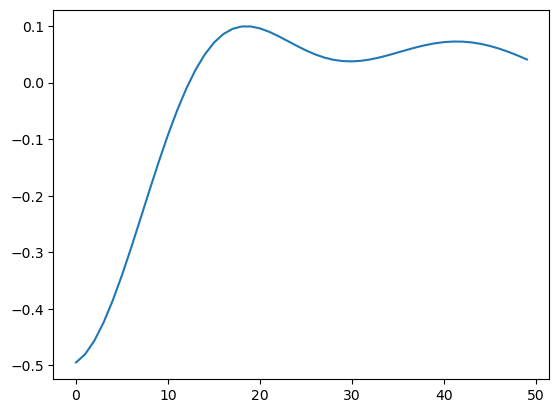

In [30]:
L = 12
H = op.heisenberg_operator(L).to_mpo(pauli=False).to_torch('cpu')
𝜓t = qtc.MPS.from_product_state(["up","down"]*(L//2))
psis = H.tdvp(init=𝜓t, time_step=-0.1j, final_time=-5.j, outputlevel=0)
Ss = []
for t, phi in tqdm(psis, ascii=True, total=100):
    Ss.append(phi.measure('z', 3).item().real)
import matplotlib.pyplot as plt
plt.plot(Ss)